## Experiment 2: Milikan Oil Drop Analysis

#### Imports

In [1]:
! python -m pip install pandas numpy matplotlib

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from where_linear import LinearDomainFinder

In [19]:
SUBDIR = "../../data/millikan_data/drop_data_csv/"
files = [
    "t1_p1.csv",
    "t1_p2.csv",
    "t1_p3.csv",
    "t1_p4.csv",
    "t1_p5.csv",
    "t2_p1.csv",
    "t2_p2.csv",
    "t3_p1.csv",
    "t4_p1.csv",
    "t4_p2.csv"
]

In [12]:
def add_in_quad(data: np.ndarray) -> float:
    sumsqr = 0.0
    for val in data:
        sumsqr += val*val
    return np.sqrt(sumsqr)

def q(ve,vg):
    d = 4.56e-3 # m
    V = 400 # V
    eta = 18.13e-6 #N*s/m^2
    b = 6.17e-6 # m*cmHg
    P = 76 #cmHg
    rho = 0.86e3 #kg/m^3
    g = 9.801 #m/s^2
    a = np.sqrt((9*eta*vg)/(2*g*rho))
    return [a,((6*np.pi*d/V)*np.sqrt((9*eta**3)/(2*rho*g))*(ve+vg)*(np.sqrt(vg))*(1+(b/(a*P)))**(-3/2))]

#### Define Linear Domain Finder object and dataframe

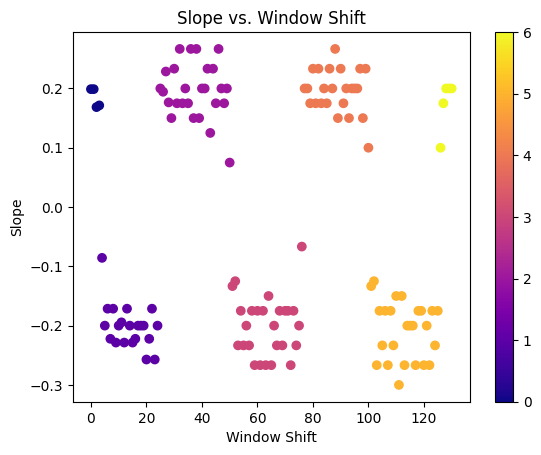

None


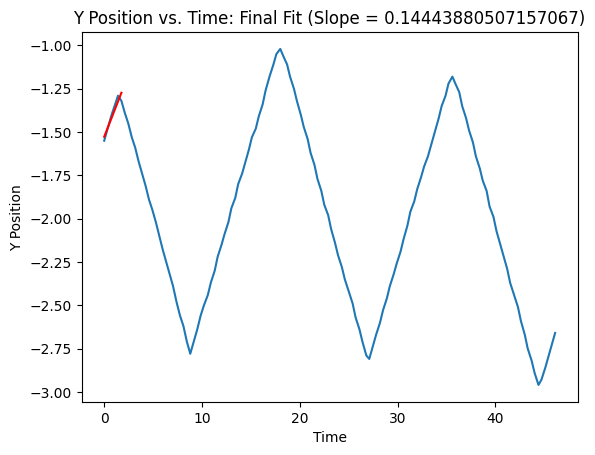

None


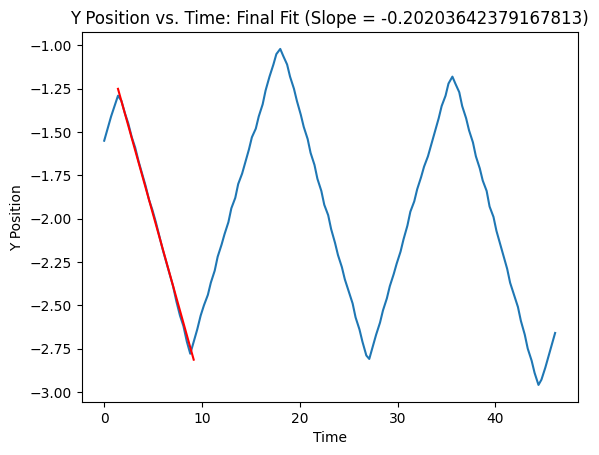

None


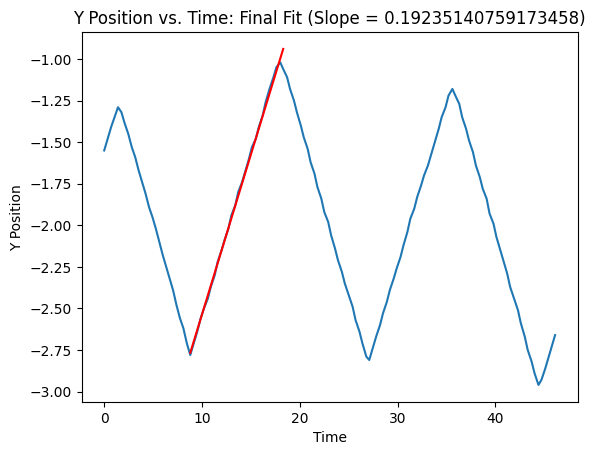

None


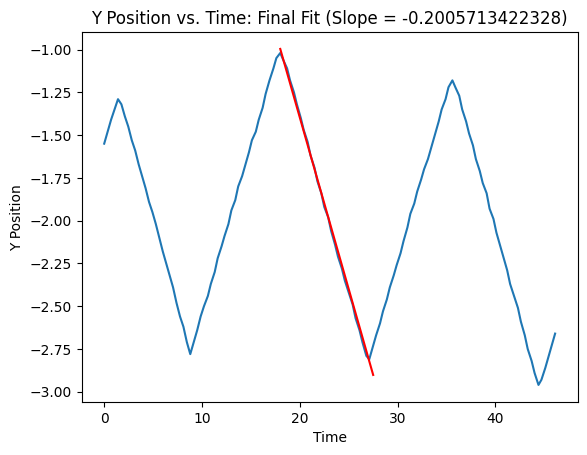

None


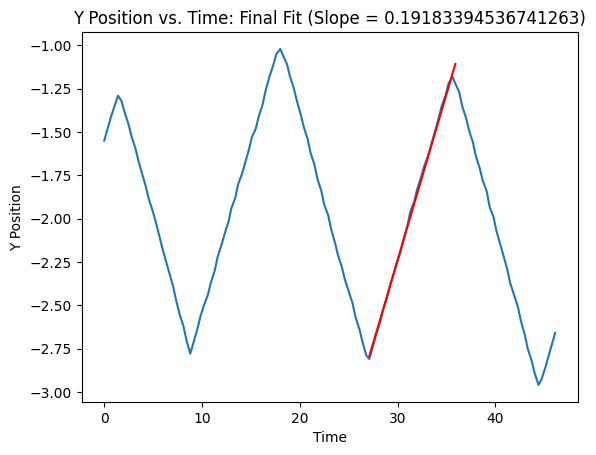

None


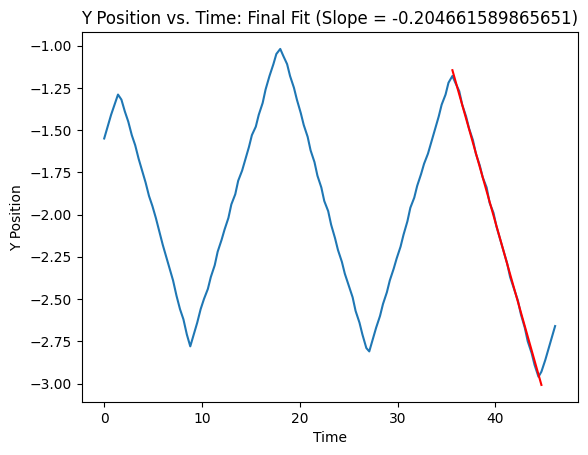

None


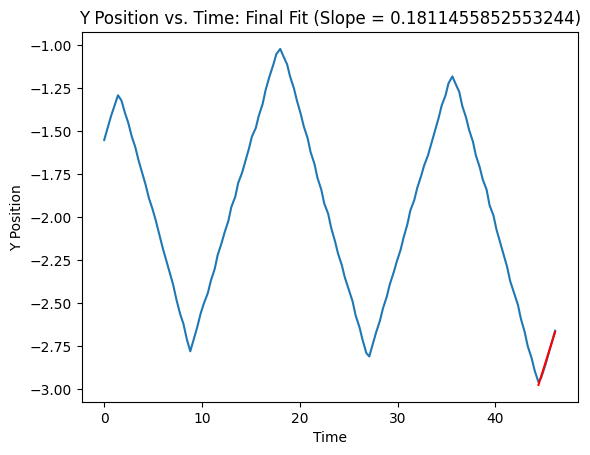

[np.float64(0.14443880507157067), np.float64(-0.20203642379167813), np.float64(0.19235140759173458), np.float64(-0.2005713422328), np.float64(0.19183394536741263), np.float64(-0.204661589865651), np.float64(0.1811455852553244)]
[np.float64(0.02478662053289684), np.float64(0.01498305479970532), np.float64(0.02598371917644855), np.float64(0.05965145751467279), np.float64(0.06413468359929787), np.float64(0.060659493381048285), np.float64(0.3627941732853126)]
V_g = 0.19209267647957362 +- 0.06919834754257205 (mm/s)
V_E = 0.20242311863004303 +- 0.08638496658563471 (mm/s)
a = 1.3635659336159005e-06
q = 1.9216284100372133e-18
# of Electrons = 11.995183583253516


LinAlgError: SVD did not converge in Linear Least Squares

In [21]:
LDF = LinearDomainFinder()
LDF.setMethod(1)
LDF.setVerbosity(1)

for file in files:
    PATH = SUBDIR + file
    df = pd.read_csv(PATH)
    LDF.setX(df["t"].to_numpy(),label="Time")
    LDF.setY(df["y"].to_numpy(),label="Y Position")

    LDF.slidingWindowFind(WIN_SIZE=2,FDEV_CUT=0.3)
    print(LDF._slopes)
    print(LDF._slope_errors)
    userInput = input("Press ENTER to continue.")

    domainSelection = range(1,len(LDF._slopes)-1)
    vg_data = []
    vg_err = []
    ve_data = []
    ve_err = []
    for i in domainSelection:
        slope = LDF._slopes[i]
        err = LDF._slope_errors[i]
        if slope > 0.0:
            vg_data.append(slope)
            vg_err.append(err)
        elif slope < 0.0:
            ve_data.append(abs(slope))
            ve_err.append(err)

    V_g = np.mean(vg_data)
    V_g_err = add_in_quad(vg_err)
    V_E = np.mean(ve_data)
    V_E_err = add_in_quad(ve_err)
    print("V_g =", V_g, "+-", V_g_err, "(mm/s)")
    print("V_E =", V_E, "+-", V_E_err, "(mm/s)")

    radius, totalCharge = q(V_E*1.0E-3, V_g*1.0E-3)
    print("a =", radius)
    print("q =", totalCharge)

    numElectrons = totalCharge / 1.602E-19
    print("# of Electrons =", numElectrons)
